### Importing necessary libraries

In [23]:
### Importing necessary libraries
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from pathlib import Path

### Importing the raw data file

In [24]:
data_path = Path.cwd().parent.joinpath("data")
file_path = os.path.join(data_path, "raw",  "olkaria_unit_1.xlsx")
file = pd.ExcelFile(file_path)

# Get the sheet names
sheet_names = file.sheet_names
print("Available sheets in the file:")
for i, name in enumerate(sheet_names, 1):
    print(f"{i}. {name}")

Available sheets in the file:
1.  SUMMARY DATA FOR UNIT 1 OLK II
2. LOAD STEAM PRES FLOW TEMP DATA
3.   scrubber inlet pre,turbine te
4. data for net power to kenya pow


In [25]:
# Load the most important sheets
df_sheet_main = pd.read_excel(file_path, sheet_name=sheet_names[1])
df_sheet_turbine = pd.read_excel(file_path, sheet_name=sheet_names[2])

In [26]:
# Sheet 1
df_sheet_main.head(10)

,Dates,Gen1 Unit Load (MW),Gen2 Unit Load (MW),Gen3 Unit Load (MW),Gen2 Vent Station Steam Pressure Bar,Gen1 Vent Station Steam Pressure Bar,Gen3 Vent Station Steam Pressure Bar,Gen1 Main steam flow (T/H),Gen2 Main steam flow (T/H),Gen3 Main steam flow (T/H),Gen1 Main Steam Temp °C(Scrubber inlet),Gen2 Main Steam Temp °C(Scrubber inlet),Gen3 Main Steam Temp °C(Scrubber inlet),Gen1 Bar (Scrubber inlet) Main steam pressure,Gen2 Bar (Scrubber inlet) Main steam pressure,Gen3 Bar (Scrubber inlet) Main steam pressure,Unnamed: 16
0,2018-01-11 00:00:00,30.5,30.1,30.3,5.47,5.47,5.46,261.3,260.1,263.6,159.1,159.2,159.1,5.0,5.0,NaN,NaN
1,2018-02-11 00:00:00,30.4,25.3,25.5,5.51,5.50,5.49,264.3,220.4,217.2,159.1,159.3,159.5,5.0,5.0,5.0,NaN
2,2018-02-11 00:00:00,30.7,30.7,NaN,5.65,5.64,NaN,266.4,266.8,NaN,159.9,159.9,NaN,5.5,5.5,NaN,NaN
3,2018-03-11 00:00:00,25.7,25.7,25.7,5.66,5.69,5.69,237.3,239.2,259.2,150.4,150.3,150.3,5.6,5.6,5.6,NaN
4,2018-03-11 00:00:00,30.8,25.0,NaN,5.49,5.51,NaN,266.2,237.9,NaN,159.2,159.4,NaN,5.4,5.4,NaN,NaN
5,2018-04-11 00:00:00,25.7,25.6,25.6,5.67,5.67,5.67,241.3,241.3,241.3,160.2,160.2,160.2,5.6,5.6,5.6,NaN
6,2018-04-11 00:00:00,25.6,24.5,25.4,5.50,5.95,5.47,243.2,25.0,232.0,159.5,159.2,159.4,5.4,5.4,5.4,NaN
7,2018-05-11 00:00:00,30.8,30.9,30.3,5.47,5.46,5.47,260.7,259.4,251.9,158.0,158.5,158.9,5.3,5.3,5.3,NaN
8,2018-05-11 00:00:00,25.3,25.6,30.4,5.42,5.45,5.45,240.0,239.0,262.0,159.0,159.0,159.0,5.3,5.3,5.3,NaN
9,2018-06-11 00:00:00,30.6,30.7,30.4,5.53,5.52,5.53,263.5,260.3,265.8,159.5,159.0,158.9,5.4,5.4,5.4,NaN


In [27]:
# Sheet 2
df_sheet_turbine.head(10)

,Date,Gen1 Main Steam Temp Tubine Inlet(°C) (LH),Gen2 Main Steam Temp Tubine Inlet(°C) (LH),Gen3 Main Steam Temp Tubine Inlet(°C) (LH),Gen1 Main Steam Temp Tubine Inlet(°C) (RH),Gen2 Main Steam Temp Tubine Inlet(°C) (RH),Gen3 Main Steam Temp Tubine Inlet(°C) (RH),Gen1 Main steam Conductivity μ MHO,Gen2 Main steam Conductivity μ MHO,Gen3 Main steam Conductivity μ MHO,Gen1 Turbine Chest Pressure (Bar g),Gen2 Turbine Chest Pressure (Bar g),Gen3 Turbine Chest Pressure (Bar g),Gen1 Turbine exhaust Steam pressure Bar a,Gen2 Turbine exhaust Steam pressure Bar a,Gen3 Turbine exhaust Steam pressure Bar a,Gen3 Turbine Exhaust Steam temp,Gen3 Turbine Exhaust Steam temp.1,Gen3 Turbine Exhaust Steam temp.2
0,2018-01-11 00:00:00,154.6,154.8,154.6,158.5,158.7,158.5,4.0,3.4,3.2,5.211,5.160,5.202,0.122,0.119,0.121,50.1,49.3,49.8
1,2018-02-11 00:00:00,154.7,155.3,155.4,158.6,159.2,159.3,3.0,10.4,6.8,5.248,4.120,4.096,0.123,0.096,0.095,50.2,45.3,44.7
2,2018-02-11 00:00:00,155.4,155.4,NaN,159.3,159.3,NaN,4.4,4.4,NaN,5.329,5.329,NaN,0.125,0.125,NaN,50.1,50.7,NaN
3,2018-03-11 00:00:00,156.1,156.1,156.1,159.9,160.0,160.0,3.8,3.8,3.8,4.662,4.657,4.657,0.139,0.140,0.140,52.4,52.4,52.4
4,2018-03-11 00:00:00,154.8,155.0,NaN,158.7,158.8,NaN,8.0,8.2,NaN,5.221,4.611,NaN,0.126,0.139,NaN,50.4,52.1,NaN
5,2018-04-11 00:00:00,156.0,156.0,156.0,159.0,159.0,159.0,3.4,3.4,3.4,4.600,4.602,4.602,0.137,0.137,0.137,52.2,52.2,52.2
6,2018-04-11 00:00:00,155.0,159.6,155.0,158.8,158.6,155.0,4.4,6.2,7.0,4.658,4.550,4.461,0.143,0.139,0.131,52.9,52.7,51.6
7,2018-05-11 00:00:00,154.4,154.7,154.6,158.3,158.0,158.4,3.0,3.0,3.4,5.200,5.123,5.053,0.116,0.112,0.111,49.2,48.5,48.0
8,2018-05-11 00:00:00,154.5,154.5,154.2,158.3,158.3,158.0,3.6,11.6,3.4,4.571,4.675,5.101,0.140,0.145,0.115,52.4,53.8,49.4
9,2018-06-11 00:00:00,154.7,154.7,154.6,158.7,158.6,158.6,3.0,2.8,3.0,5.235,5.234,5.189,0.118,0.115,0.114,49.5,49.0,48.7


In [28]:
# Get their shapes
print(df_sheet_main.shape)
print(df_sheet_turbine.shape)


(189, 17)
(189, 19)


In [29]:
# Create a strict preprocessing function for the individual raw slices
def preprocess_raw_slice(df, columns_list, is_turbine=False):
    df_copy = df.iloc[:, columns_list].copy()
    df_copy.columns = [
        'date', 'load_MW', 'vent_pressure_bar', 'steam_flow_th', 'scrubber_temp_C', 'scrubber_pressure_bar'
    ] if not is_turbine else [
        'date', 'lh_inlet_temp_C', 'rh_inlet_temp_C', 'conductivity_uMHO', 'chest_pressure_barg', 'exhaust_pressure_bara', 'exhaust_temp_C'
    ]

    # 1. Drop the headers/hours descriptive rows if they are present
    df_copy = df_copy[df_copy['date'] != 'HOURS']

    # 2. Drop rows where date itself is completely missing
    df_copy = df_copy.dropna(subset=['date'])

    # 3. Enforce proper datatypes immediately
    df_copy['date'] = pd.to_datetime(df_copy['date'], errors='coerce')

    # 4. Drop rows where date failed to parse (now NaNs)
    df_copy = df_copy.dropna(subset=['date'])

    # Reset index so positional alignment matches cleanly
    return df_copy.reset_index(drop=True)

# Now extract clean, standardized dataframes
gen1_load_raw = preprocess_raw_slice(df_sheet_main, [0, 1, 4, 7, 10, 13], is_turbine=False)
gen2_load_raw = preprocess_raw_slice(df_sheet_main, [0, 2, 5, 8, 11, 14], is_turbine=False)
gen3_load_raw = preprocess_raw_slice(df_sheet_main, [0, 3, 6, 9, 12, 15], is_turbine=False)

gen1_turbine_raw = preprocess_raw_slice(df_sheet_turbine, [0, 1, 4, 7, 10, 13, 16], is_turbine=True)
gen2_turbine_raw = preprocess_raw_slice(df_sheet_turbine, [0, 2, 5, 8, 11, 14, 17], is_turbine=True)
gen3_turbine_raw = preprocess_raw_slice(df_sheet_turbine, [0, 3, 6, 9, 12, 15, 18], is_turbine=True)


print("Gen1 Load raw shape:", gen1_load_raw.shape)
display(gen1_load_raw.head(5))

print("Gen2 Load raw shape:", gen2_load_raw.shape)
display(gen2_load_raw.head(5))

print("Gen3 Load raw shape:", gen3_load_raw.shape)
display(gen3_load_raw.head(5))

print("Gen1 Turbine raw shape:", gen1_turbine_raw.shape)
display(gen1_turbine_raw.head(5))

print("Gen2 Turbine raw shape:", gen2_turbine_raw.shape)
display(gen2_turbine_raw.head(5))

print("Gen3 Turbine raw shape:", gen3_turbine_raw.shape)
display(gen3_turbine_raw.head(5))


Gen1 Load raw shape: (186, 6)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar
0,2018-01-11,30.5,5.47,261.3,159.1,5.0
1,2018-02-11,30.4,5.51,264.3,159.1,5.0
2,2018-02-11,30.7,5.65,266.4,159.9,5.5
3,2018-03-11,25.7,5.66,237.3,150.4,5.6
4,2018-03-11,30.8,5.49,266.2,159.2,5.4


Gen2 Load raw shape: (186, 6)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar
0,2018-01-11,30.1,5.47,260.1,159.2,5.0
1,2018-02-11,25.3,5.50,220.4,159.3,5.0
2,2018-02-11,30.7,5.64,266.8,159.9,5.5
3,2018-03-11,25.7,5.69,239.2,150.3,5.6
4,2018-03-11,25.0,5.51,237.9,159.4,5.4


Gen3 Load raw shape: (186, 6)


...

,date,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,154.6,158.5,4.0,5.211,0.122,50.1
1,2018-02-11,154.7,158.6,3.0,5.248,0.123,50.2
2,2018-02-11,155.4,159.3,4.4,5.329,0.125,50.1
3,2018-03-11,156.1,159.9,3.8,4.662,0.139,52.4
4,2018-03-11,154.8,158.7,8.0,5.221,0.126,50.4


Gen2 Turbine raw shape: (184, 7)


,date,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,154.8,158.7,3.4,5.160,0.119,49.3
1,2018-02-11,155.3,159.2,10.4,4.120,0.096,45.3
2,2018-02-11,155.4,159.3,4.4,5.329,0.125,50.7
3,2018-03-11,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,155.0,158.8,8.2,4.611,0.139,52.1


Gen3 Turbine raw shape: (184, 7)


,date,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,154.6,158.5,3.2,5.202,0.121,49.8
1,2018-02-11,155.4,159.3,6.8,4.096,0.095,44.7
2,2018-02-11,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-03-11,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Define the known break-point date that causes the structural shift
shift_date = pd.to_datetime('2019-02-28')

if shift_date in gen1_load_raw['date'].values:
    # Locate where the missing row needs to sit in the turbine data sequence
    target_idx = gen1_load_raw[gen1_load_raw['date'] == shift_date].index[0]

    # Build an empty padding row matching the turbine structure
    pad_row = pd.DataFrame(columns=gen1_turbine_raw.columns)
    pad_row.loc[0] = np.nan
    pad_row['date'] = shift_date

    # Inject the padding row into Gen 1 Turbine to force subsequent positions back into alignment
    gen1_turbine_clean = pd.concat(
        [gen1_turbine_raw.iloc[:target_idx], pad_row, gen1_turbine_raw.iloc[target_idx:]],
        ignore_index=True
    )
    print(f"Successfully patched structural shift for Gen 1 Turbine data at index: {target_idx}")

Successfully patched structural shift for Gen 1 Turbine data at index: 158


In [31]:
def merge_generator_units(load_df, turbine_df):
    # Strip out the date column from turbine to avoid duplicate ._x or ._y tags
    turb_no_date = turbine_df.drop(columns=['date'], errors='ignore')
    return pd.concat([load_df, turb_no_date], axis=1)

# Assemble your target clean analytical dataframes
gen1_raw = merge_generator_units(gen1_load_raw, gen1_turbine_raw)
gen2_raw = merge_generator_units(gen2_load_raw, gen2_turbine_raw)
gen3_raw = merge_generator_units(gen3_load_raw, gen3_turbine_raw)

print("=== FINAL RESTRUCTURED SHAPES ===")
print()
print("Gen1 raw shape:", gen1_raw.shape)
display(gen1_raw.head(5))
print()
print("Gen2 raw shape:", gen2_raw.shape)
display(gen2_raw.head(5))
print()
print("Gen3 raw shape:", gen3_raw.shape)
display(gen3_raw.head(5))

=== FINAL RESTRUCTURED SHAPES ===

Gen1 raw shape: (186, 12)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,30.5,5.47,261.3,159.1,5.0,154.6,158.5,4.0,5.211,0.122,50.1
1,2018-02-11,30.4,5.51,264.3,159.1,5.0,154.7,158.6,3.0,5.248,0.123,50.2
2,2018-02-11,30.7,5.65,266.4,159.9,5.5,155.4,159.3,4.4,5.329,0.125,50.1
3,2018-03-11,25.7,5.66,237.3,150.4,5.6,156.1,159.9,3.8,4.662,0.139,52.4
4,2018-03-11,30.8,5.49,266.2,159.2,5.4,154.8,158.7,8.0,5.221,0.126,50.4



Gen2 raw shape: (186, 12)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,30.1,5.47,260.1,159.2,5.0,154.8,158.7,3.4,5.160,0.119,49.3
1,2018-02-11,25.3,5.50,220.4,159.3,5.0,155.3,159.2,10.4,4.120,0.096,45.3
2,2018-02-11,30.7,5.64,266.8,159.9,5.5,155.4,159.3,4.4,5.329,0.125,50.7
3,2018-03-11,25.7,5.69,239.2,150.3,5.6,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,25.0,5.51,237.9,159.4,5.4,155.0,158.8,8.2,4.611,0.139,52.1



Gen3 raw shape: (186, 12)


,date,load_MW,vent_pressure_bar,steam_flow_th,scrubber_temp_C,scrubber_pressure_bar,lh_inlet_temp_C,rh_inlet_temp_C,conductivity_uMHO,chest_pressure_barg,exhaust_pressure_bara,exhaust_temp_C
0,2018-01-11,30.3,5.46,263.6,159.1,NaN,154.6,158.5,3.2,5.202,0.121,49.8
1,2018-02-11,25.5,5.49,217.2,159.5,5.0,155.4,159.3,6.8,4.096,0.095,44.7
2,2018-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-03-11,25.7,5.69,259.2,150.3,5.6,156.1,160.0,3.8,4.657,0.140,52.4
4,2018-03-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
raw_path = Path.cwd().parent / "data" / "raw"

gen1_raw.to_csv(raw_path / "gen1_raw.csv", index=False)
gen2_raw.to_csv(raw_path / "gen2_raw.csv", index=False)
gen3_raw.to_csv(raw_path / "gen3_raw.csv", index=False)

print("Saved successfully:")
print(f"  gen1_raw.csv — {gen1_raw.shape}")
print(f"  gen2_raw.csv — {gen2_raw.shape}")
print(f"  gen3_raw.csv — {gen3_raw.shape}")

Saved successfully:
  gen1_raw.csv — (186, 12)
  gen2_raw.csv — (186, 12)
  gen3_raw.csv — (186, 12)


### DATA CLEANING: Missing values, Data type

In [33]:

print("=== GEN1 DTYPES ===")
print(gen1_raw.dtypes)
print()
print("=== GEN2 DTYPES ===")
print(gen2_raw.dtypes)
print()
print("=== GEN3 DTYPES ===")
print(gen3_raw.dtypes)

=== GEN1 DTYPES ===
date                     datetime64[us]
load_MW                         float64
vent_pressure_bar               float64
steam_flow_th                   float64
scrubber_temp_C                 float64
scrubber_pressure_bar           float64
lh_inlet_temp_C                 float64
rh_inlet_temp_C                 float64
conductivity_uMHO               float64
chest_pressure_barg             float64
exhaust_pressure_bara           float64
exhaust_temp_C                  float64
dtype: object

=== GEN2 DTYPES ===
date                     datetime64[us]
load_MW                         float64
vent_pressure_bar               float64
steam_flow_th                   float64
scrubber_temp_C                 float64
scrubber_pressure_bar           float64
lh_inlet_temp_C                 float64
rh_inlet_temp_C                 float64
conductivity_uMHO               float64
chest_pressure_barg             float64
exhaust_pressure_bara           float64
exhaust_temp_C           

In [34]:
# First check null counts before doing anything
print("=== NULLS BEFORE IMPUTATION ===")
print("Gen1:")
print(gen1_raw.isnull().sum())
print()
print("Gen2:")
print(gen2_raw.isnull().sum())
print()
print("Gen3:")
print(gen3_raw.isnull().sum())
print("-" * 40)

# Drop rows where date itself is null — we cannot use a row with no date
gen1_raw = gen1_raw.dropna(subset=['date']).reset_index(drop=True)
gen2_raw = gen2_raw.dropna(subset=['date']).reset_index(drop=True)
gen3_raw = gen3_raw.dropna(subset=['date']).reset_index(drop=True)

# Columns to handle via chronological propagation
ffill_cols = [
    'load_MW', 'vent_pressure_bar', 'steam_flow_th',
    'scrubber_temp_C', 'scrubber_pressure_bar',
    'lh_inlet_temp_C', 'rh_inlet_temp_C',
    'chest_pressure_barg', 'exhaust_pressure_bara', 'exhaust_temp_C'
]

# Process each generator dataframe
for i, df in enumerate([gen1_raw, gen2_raw, gen3_raw], 1):

    # CRITICAL FIX: Chain bfill() after ffill() to handle missing values at index 0
    df[ffill_cols] = df[ffill_cols].ffill().bfill()

    # Handle conductivity imputation via localized median calculation
    # NOTE: pd.median() automatically excludes NaNs, so it's completely safe
    median_cond = df['conductivity_uMHO'].median()
    df['conductivity_uMHO'] = df['conductivity_uMHO'].fillna(median_cond)
    print(f"Gen{i} conductivity median used for fill: {median_cond}")

# Final validation sanity check
print("\n=== NULLS AFTER IMPUTATION ===")
print("Gen1:")
print(gen1_raw.isnull().sum())
print()
print("Gen2:")
print(gen2_raw.isnull().sum())
print()
print("Gen3:")
print(gen3_raw.isnull().sum())

=== NULLS BEFORE IMPUTATION ===
Gen1:
date                      0
load_MW                   8
vent_pressure_bar         8
steam_flow_th             8
scrubber_temp_C           8
scrubber_pressure_bar     9
lh_inlet_temp_C           9
rh_inlet_temp_C           9
conductivity_uMHO        10
chest_pressure_barg       9
exhaust_pressure_bara     9
exhaust_temp_C            9
dtype: int64

Gen2:
date                      0
load_MW                  10
vent_pressure_bar        10
steam_flow_th             9
scrubber_temp_C          10
scrubber_pressure_bar    10
lh_inlet_temp_C          12
rh_inlet_temp_C          12
conductivity_uMHO        11
chest_pressure_barg      11
exhaust_pressure_bara    10
exhaust_temp_C           10
dtype: int64

Gen3:
date                      0
load_MW                  11
vent_pressure_bar         9
steam_flow_th             5
scrubber_temp_C          10
scrubber_pressure_bar    11
lh_inlet_temp_C          12
rh_inlet_temp_C          13
conductivity_uMHO        1

In [35]:
# Save cleaned data
raw_path = Path.cwd().parent / "data" / "processed"
gen1_raw.to_csv(raw_path / "gen1_clean.csv", index=False)
gen2_raw.to_csv(raw_path / "gen2_clean.csv", index=False)
gen3_raw.to_csv(raw_path / "gen3_clean.csv", index=False)

print("Saved successfully:")
print(f"  gen1_clean.csv — {gen1_raw.shape}")
print(f"  gen2_clean.csv — {gen2_raw.shape}")
print(f"  gen3_clean.csv — {gen3_raw.shape}")

Saved successfully:
  gen1_clean.csv — (186, 12)
  gen2_clean.csv — (186, 12)
  gen3_clean.csv — (186, 12)


### Exploratory Data Analysis (EDA)

In [36]:
# Load the clean version
clean_file_path = os.path.join(data_path, "processed")

def load_and_prepare(filename):
    df = pd.read_csv(os.path.join(clean_file_path, filename))
    # Parse dates immediately on load
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.sort_values('date').reset_index(drop=True)
    # Trim ffill-fabricated rows — drop anything after first gap > 60 days
    date_diffs = df['date'].diff().dt.days
    big_gap_idx = date_diffs[date_diffs > 60].index
    if len(big_gap_idx) > 0:
        cutoff_idx = big_gap_idx[0]
        df = df.iloc[:cutoff_idx].reset_index(drop=True)
    return df

gen1_clean = load_and_prepare("gen1_clean.csv")
gen2_clean = load_and_prepare("gen2_clean.csv")
gen3_clean = load_and_prepare("gen3_clean.csv")

# Confirm
for name, df in [('Gen1', gen1_clean), ('Gen2', gen2_clean), ('Gen3', gen3_clean)]:
    print(f"{name} — shape: {df.shape} | {df['date'].min().date()} → {df['date'].max().date()}")

Gen1 — shape: (182, 12) | 2018-01-11 → 2019-12-03
Gen2 — shape: (182, 12) | 2018-01-11 → 2019-12-03
Gen3 — shape: (182, 12) | 2018-01-11 → 2019-12-03


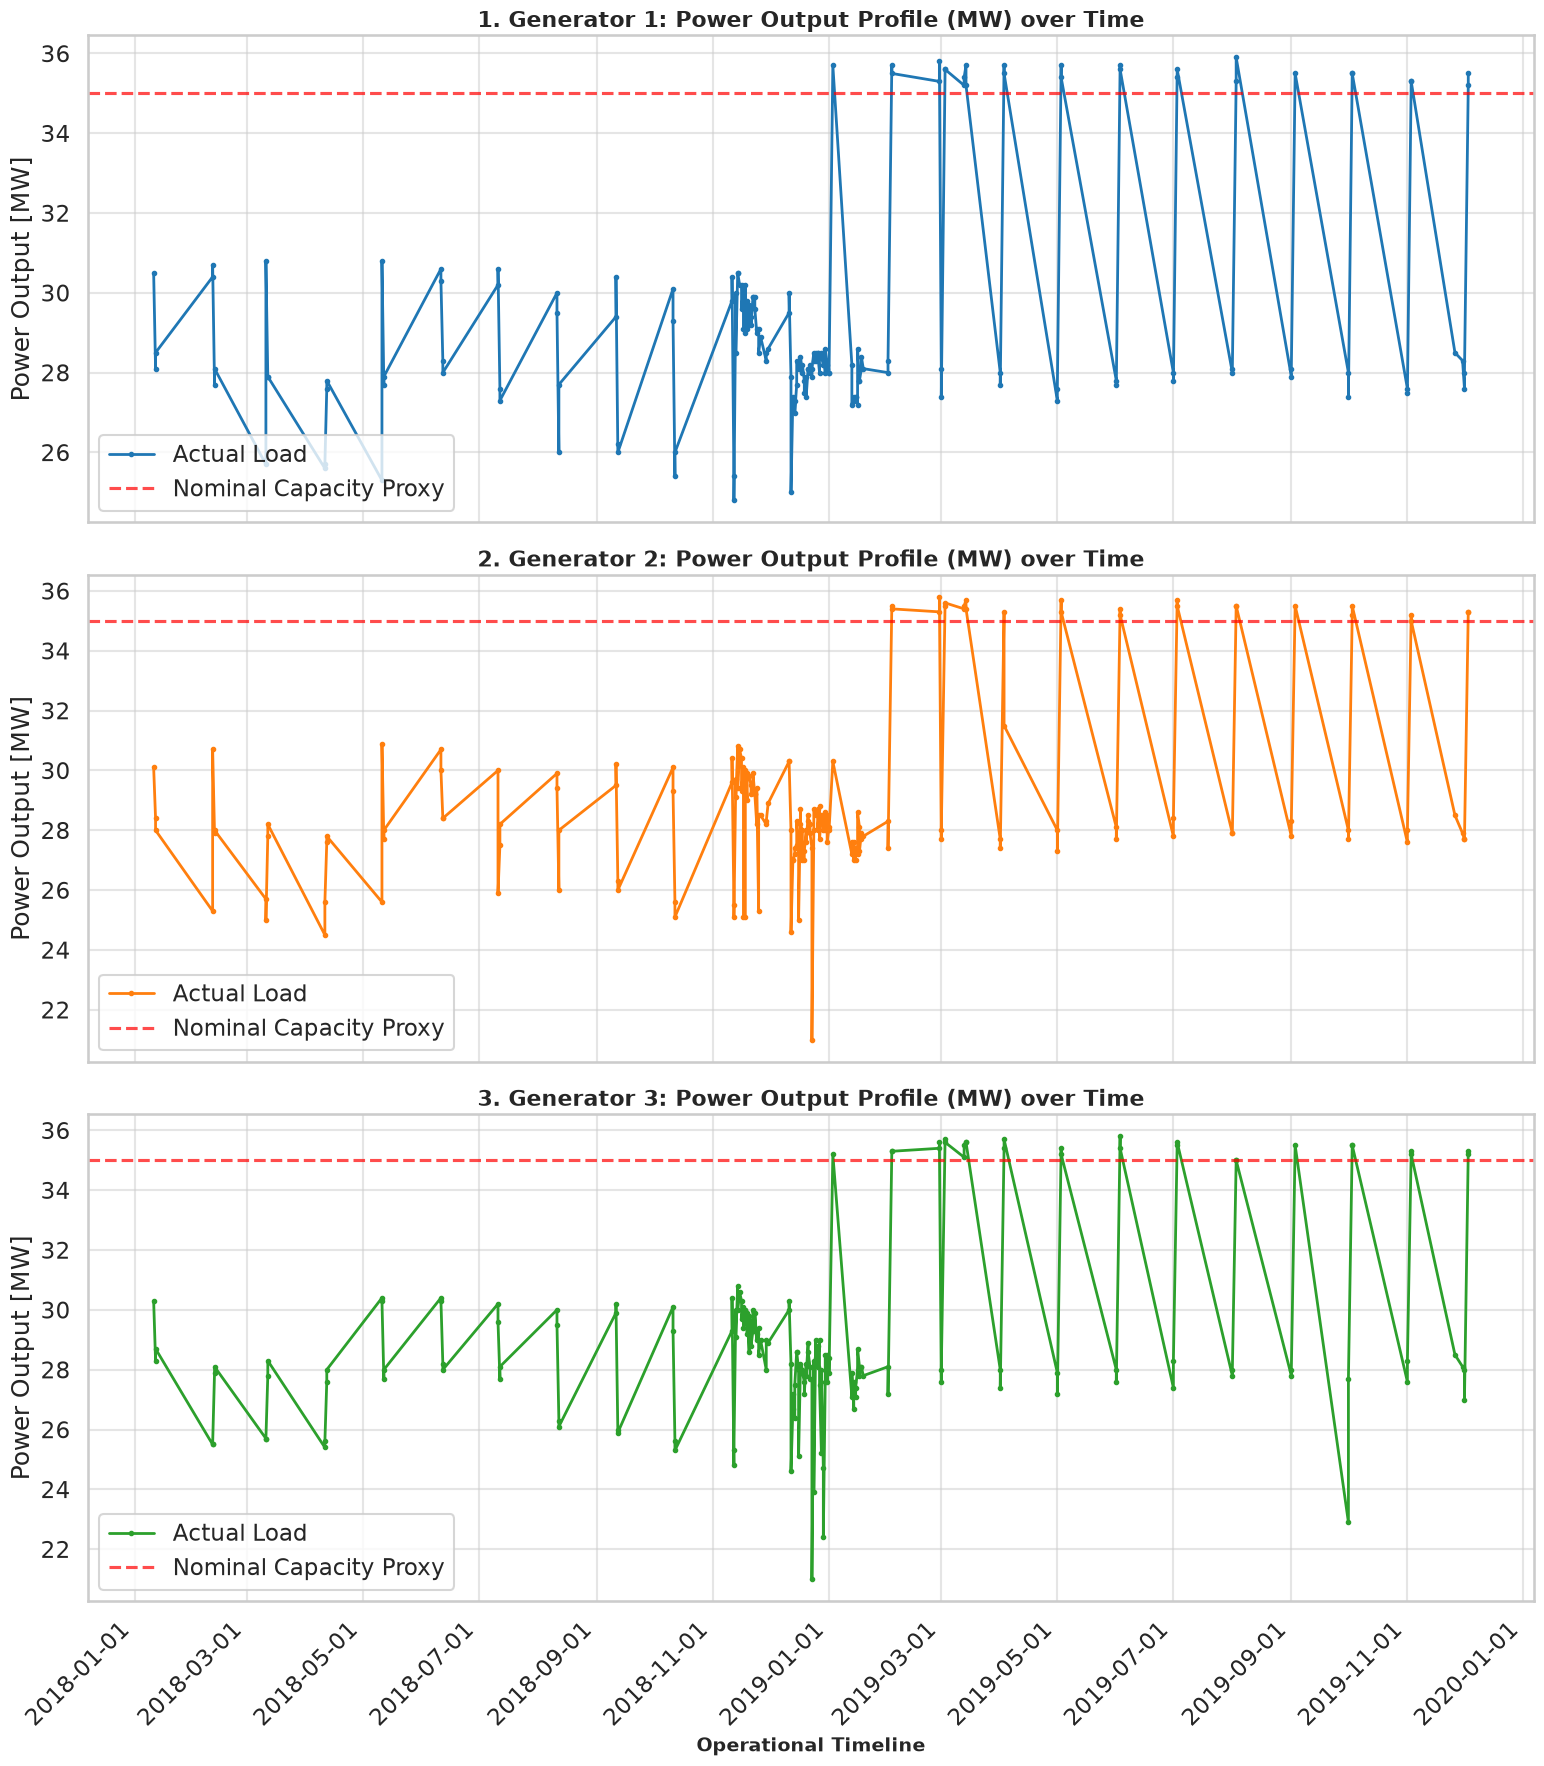

In [37]:
# Set a professional plotting style
sns.set_theme(style="whitegrid", context="talk")

# sharex=True locks the timelines together so they all align perfectly by date
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# 1. Generator 1 — Operational Load Profile
axes[0].plot(gen1_clean['date'], gen1_clean['load_MW'], color='#1f77b4', linewidth=2, marker='o', markersize=3, label='Actual Load')
axes[0].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Nominal Capacity Proxy')
axes[0].set_title('1. Generator 1: Power Output Profile (MW) over Time', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Power Output [MW]')
axes[0].legend(loc='lower left')

# 2. Generator 2 — Operational Load Profile
axes[1].plot(gen2_clean['date'], gen2_clean['load_MW'], color='#ff7f0e', linewidth=2, marker='o', markersize=3, label='Actual Load')
axes[1].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Nominal Capacity Proxy')
axes[1].set_title('2. Generator 2: Power Output Profile (MW) over Time', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Power Output [MW]')
axes[1].legend(loc='lower left')

# 3. Generator 3 — Operational Load Profile
axes[2].plot(gen3_clean['date'], gen3_clean['load_MW'], color='#2ca02c', linewidth=2, marker='o', markersize=3, label='Actual Load')
axes[2].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Nominal Capacity Proxy')
axes[2].set_title('3. Generator 3: Power Output Profile (MW) over Time', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Power Output [MW]')
axes[2].legend(loc='lower left')

# ─── THE X-AXIS FIXES (Applied only to the bottom axis, axes[2]) ───
# Rotate the dates so they never overlap
plt.xticks(rotation=45, ha='right')

# Force a tick mark exactly every 2 months instead of printing every single date row
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[2].set_xlabel('Operational Timeline', fontsize=14, fontweight='bold')

# Set tight layout so the rotated text doesn't get cut off at the very bottom
plt.tight_layout()
plt.show()

In [38]:
# Define nominal design capacity for an Olkaria II unit
NOMINAL_CAPACITY_MW = 35.0

def generate_unit_profile(df, name):
    # Calculate key high-grade engineering metrics
    mean_load = df['load_MW'].mean()
    max_load = df['load_MW'].max()
    min_load = df['load_MW'].min()
    std_dev = df['load_MW'].std()

    # Capacity Factor = (Average Power Generated / Nominal Design Capacity) * 100
    capacity_factor = (mean_load / NOMINAL_CAPACITY_MW) * 100

    # Off-Design Volatility Coefficient (Relative standard deviation)
    volatility_coef = (std_dev / mean_load) * 100

    # Time spent severely derated (Operating below 30 MW)
    derated_time_pct = (df['load_MW'] < 30.0).mean() * 100

    profile = {
        "Unit Baseline": name,
        "Mean Output (MW)": round(mean_load, 2),
        "Max Output (MW)": round(max_load, 2),
        "Min Output (MW)": round(min_load, 2),
        "Standard Deviation (MW)": round(std_dev, 2),
        "Capacity Factor (%)": round(capacity_factor, 2),
        "Volatility Coef (%)": round(volatility_coef, 2),
        "Downtime/Derated Presence (%)": round(derated_time_pct, 2)
    }
    return profile

# Compile profiles for all three power stations
g1_prof = generate_unit_profile(gen1_raw, "Generator 1")
g2_prof = generate_unit_profile(gen2_raw, "Generator 2")
g3_prof = generate_unit_profile(gen3_raw, "Generator 3")

# Display as a clean comparative engineering table
df_profiles = pd.DataFrame([g1_prof, g2_prof, g3_prof])
display(df_profiles)

,Unit Baseline,Mean Output (MW),Max Output (MW),Min Output (MW),Standard Deviation (MW),Capacity Factor (%),Volatility Coef (%),Downtime/Derated Presence (%)
0,Generator 1,29.41,35.9,24.8,2.82,84.02,9.57,73.66
1,Generator 2,29.10,35.8,21.0,2.91,83.15,10.02,76.34
2,Generator 3,29.15,35.8,21.0,3.04,83.28,10.43,73.66


# Quantitative Baseline Profiling and Off-Design Operational Analysis

The statistical characterization of the six-year operational dataset provides the first quantitative evidence that the three generating units are operating under persistent off-design conditions. Rather than treating the dataset as a collection of power measurements, these statistics establish the operational envelope within which the proposed ANN surrogate model and NSGA-II optimizer must function. Each metric therefore has both thermodynamic significance and direct implications for the optimization framework.

---

## 1. Capacity Factor Deficit

### Observed Values
| Generator Unit | Observed Net Capacity Factor (%) |
| :--- | :---: |
| **Generator 1** | 84.02% |
| **Generator 2** | 83.15% |
| **Generator 3** | 83.28% |

Geothermal flash power plants are designed primarily for continuous base-load operation. Unlike solar or wind generation, geothermal resources are capable of supplying nearly constant thermal energy throughout the year, allowing well-managed facilities worldwide to achieve annual design capacity factors approaching or exceeding 90% to 95% under nominal conditions (Zarrouk & Moon, 2014).

The observed capacity factors of approximately 83% indicate that the units operated below their expected utilization levels during the study period. Capacity factor alone does not identify the underlying cause of this reduction, since lower values may result from scheduled maintenance, steam field management, equipment degradation, reservoir changes, or grid dispatch constraints. Nevertheless, the sustained reduction across all three units suggests that additional recoverable generation may exist.

This observation provides the engineering motivation for investigating a double-flash configuration. Significant thermal energy remains in the separated brine leaving the first flash separator. Introducing a secondary flash stage allows part of this residual enthalpy to be converted into additional steam, increasing plant output and improving overall energy and resource utilization (DiPippo, 2016; Zarrouk & Moon, 2014). The present capacity factor deficit therefore represents a measurable performance gap that the proposed optimization framework seeks to reduce rather than assuming that the entire deficit can be recovered.

---

## 2. Quantifying Off-Design Operation

The coefficient of variation ($C_v$) was calculated as:

$$
C_v = \frac{\sigma}{\mu} \times 100
$$

Where:
* $\sigma$ is the sample standard deviation of generator output.
* $\mu$ is the sample mean generator output.

### Volatility Profiles
| Generator Unit | Standard Deviation ($\sigma$, MW) | Coefficient of Variation ($C_v$, %) |
| :--- | :---: | :---: |
| **Generator 1** | 2.82 | 9.57% |
| **Generator 2** | 2.91 | 10.02% |
| **Generator 3** | 3.04 | 10.43% |

All three generators exhibit coefficients of variation close to 10%, indicating substantial fluctuations in electrical output over the six-year operating period. These fluctuations are consistent with geothermal systems operating away from their nominal design conditions, where variations in steam mass flow rate, separator pressure, fluid enthalpy, and wellhead pressure continuously shift the turbine operating point (DiPippo, 2016).

Off-design turbine behaviour is inherently nonlinear because turbine isentropic efficiency depends simultaneously on fluid pressure ratios, inlet steam quality, mass flow rate, and rotor blade aerodynamic characteristics. Consequently, simplified steady-state thermodynamic equations often become insufficient for accurately representing plant behaviour across the complete operating envelope.

Advanced engineering literature confirms that capturing these complex, non-linear relationships across a volatile operating space requires data-driven modeling approaches. Machine learning surrogate models, particularly Artificial Neural Networks (ANN), are capable of mapping these chaotic multi-variable transitions with significantly higher predictive accuracy under variable operating conditions than rigid analytical equations. The observed variability therefore provides a strong justification for adopting ANN-based surrogate modelling within the proposed optimization framework.

---

## 3. Derated Operating Region

The operational statistics indicate that the generators remained within the defined derated operating region for approximately 74% to 76% of the observation period.

### Choked Window Presence
| Generator Unit | Derated Operation Presence (%) |
| :--- | :---: |
| **Generator 1** | 73.66% |
| **Generator 2** | 76.34% |
| **Generator 3** | 73.66% |

Assuming the derated threshold has been consistently defined as generator output below 30 MW, these results indicate that the plant spends the majority of its operational life below its nominal generating capacity.

Partial-load operation is known to reduce overall thermodynamic performance because turbine expansion, separator conditions, and steam utilization deviate from their optimal design points. Previous exergy analyses of geothermal power systems have demonstrated that off-design operation generally increases internal irreversibilities, drives higher localized entropy generation, and drastically reduces the conversion efficiency of the available geothermal resource (DiPippo, 2016; Kanoglu & Bolatturk, 2008).

From an optimization perspective, this observation is particularly important. Since the plant operates under derated conditions for most of its operational history, the optimization framework should be trained and evaluated primarily within this dominant operating region rather than only under nominal full-load conditions. This ensures that the NSGA-II algorithm searches for operating conditions that are representative of actual plant behaviour.

---

## 4. Evidence for Unit-Specific Surrogate Models

The three generating units exhibit remarkably similar average outputs and capacity factors, suggesting that they experience common external influences associated with the shared geothermal reservoir and steam gathering system. However, their extreme operating boundaries differ noticeably under high-stress states.

### Operational Floors
| Generator Unit | Absolute Minimum Output (MW) |
| :--- | :---: |
| **Generator 1** | 24.80 |
| **Generator 2** | 21.01 |
| **Generator 3** | 21.03 |

The deeper minimum outputs observed for Generators 2 and 3 indicate that the units do not respond identically under severe operating conditions. These differences may arise from unit-specific factors such as localized turbine degradation, separator efficiency anomalies, steam pipeline thermal losses, chemical scaling rates, or distinct maintenance histories.



Although the generators share the same geothermal resource, the statistical evidence suggests that each unit possesses its own distinct operational response characteristics. This provides a reasonable basis for training independent ANN surrogate models for each generator instead of assuming that a single generalized model can accurately represent all three units. The effectiveness of this modelling strategy will ultimately be evaluated through comparative prediction accuracy using metrics such as Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Coefficient of Determination ($R^2$).

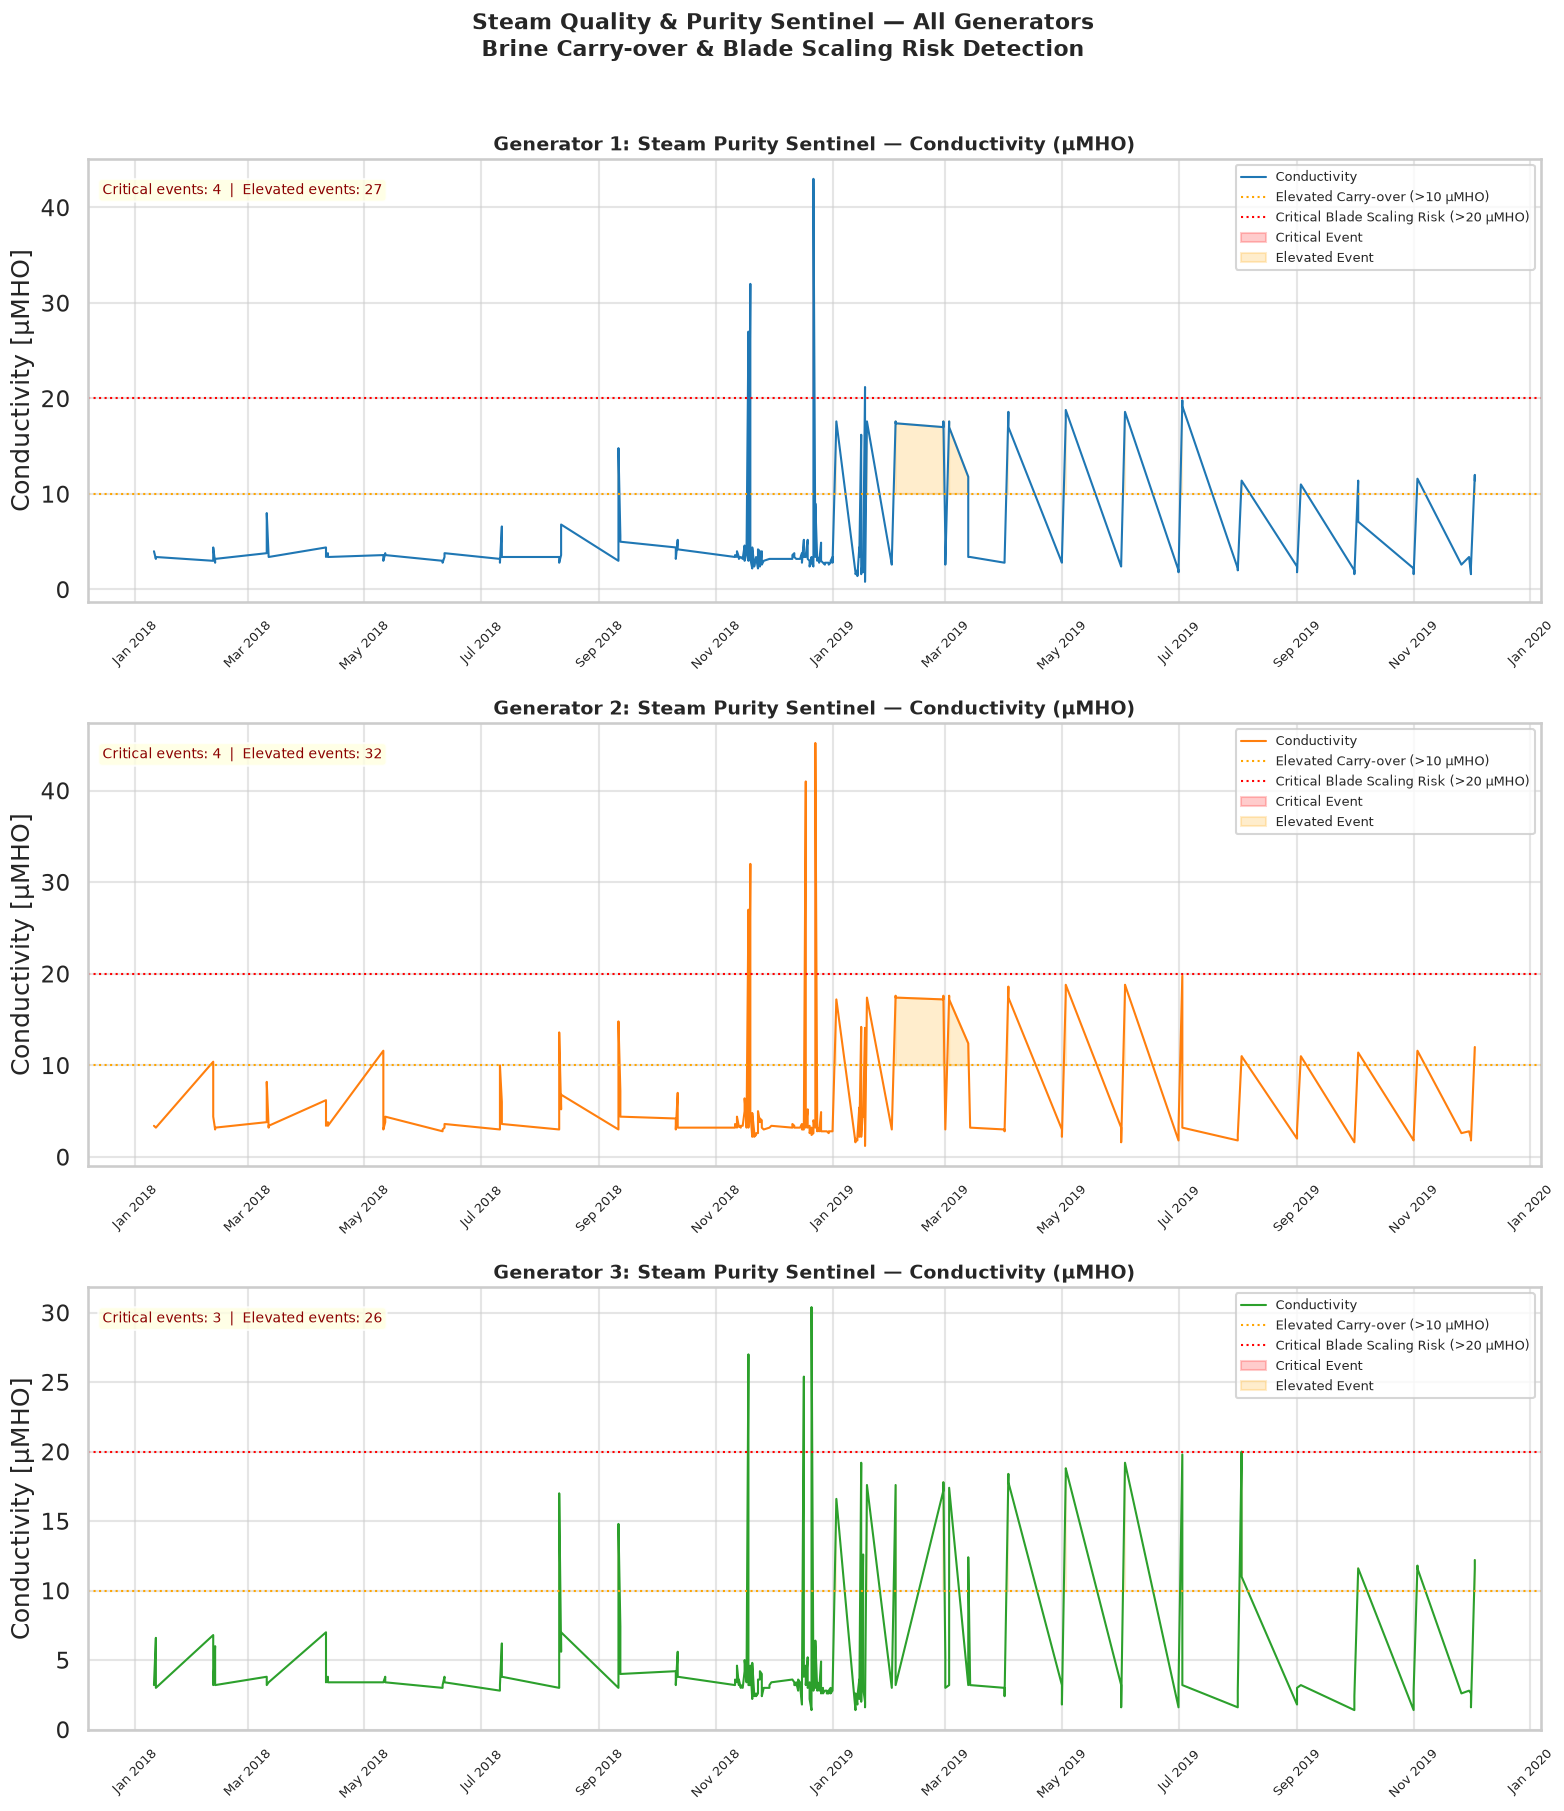

In [39]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=False)

generators = [
    (gen1_clean, 'Generator 1', '#1f77b4'),
    (gen2_clean, 'Generator 2', '#ff7f0e'),
    (gen3_clean, 'Generator 3', '#2ca02c'),
]

for ax, (df, name, color) in zip(axes, generators):
    # Make sure date is datetime
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    ax.plot(df['date'], df['conductivity_uMHO'],
            color=color, linewidth=1.5, label='Conductivity')

    ax.axhline(y=10.0, color='orange', linestyle=':', linewidth=1.5,
               label='Elevated Carry-over (>10 μMHO)')
    ax.axhline(y=20.0, color='red', linestyle=':', linewidth=1.5,
               label='Critical Blade Scaling Risk (>20 μMHO)')

    ax.fill_between(df['date'], 20.0, df['conductivity_uMHO'],
                    where=(df['conductivity_uMHO'] > 20.0),
                    color='red', alpha=0.2, label='Critical Event')

    ax.fill_between(df['date'], 10.0, df['conductivity_uMHO'],
                    where=(df['conductivity_uMHO'] > 10.0) & (df['conductivity_uMHO'] <= 20.0),
                    color='orange', alpha=0.2, label='Elevated Event')

    ax.set_title(f'{name}: Steam Purity Sentinel — Conductivity (μMHO)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Conductivity [μMHO]')
    ax.legend(loc='upper right', fontsize=9)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    critical = (df['conductivity_uMHO'] > 20.0).sum()
    elevated = ((df['conductivity_uMHO'] > 10.0) & (df['conductivity_uMHO'] <= 20.0)).sum()
    ax.text(0.01, 0.92,
            f'Critical events: {critical}  |  Elevated events: {elevated}',
            transform=ax.transAxes,
            fontsize=10, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Steam Quality & Purity Sentinel — All Generators\nBrine Carry-over & Blade Scaling Risk Detection',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

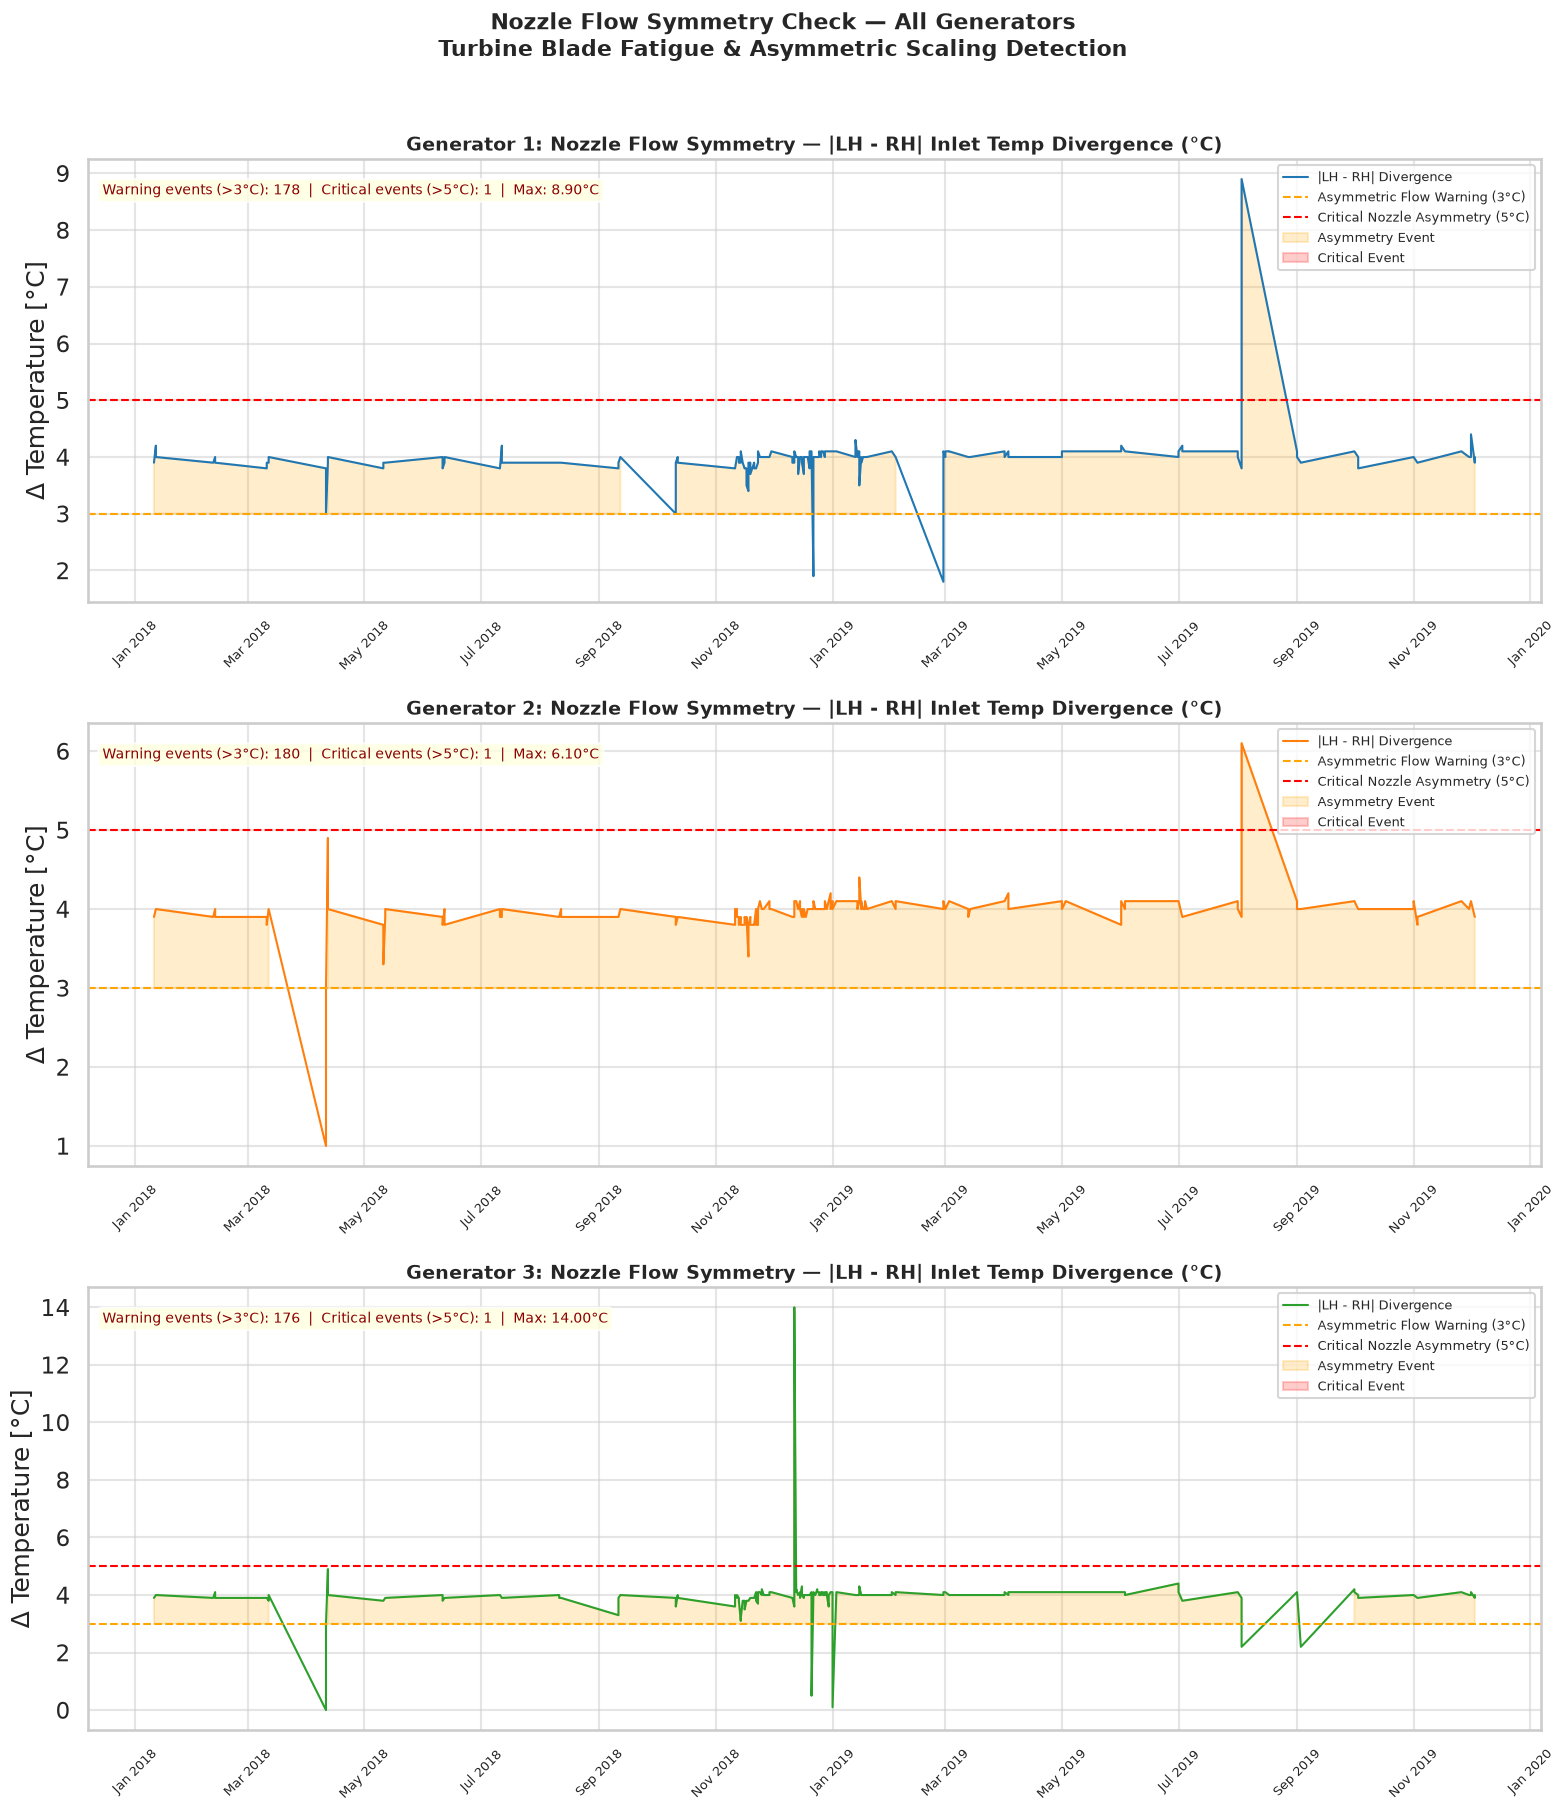

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=False)

generators = [
    (gen1_clean, 'Generator 1', '#1f77b4'),
    (gen2_clean, 'Generator 2', '#ff7f0e'),
    (gen3_clean, 'Generator 3', '#2ca02c'),
]

for ax, (df, name, color) in zip(axes, generators):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # Compute absolute divergence
    divergence = (df['lh_inlet_temp_C'] - df['rh_inlet_temp_C']).abs()

    ax.plot(df['date'], divergence, color=color, linewidth=1.5, label='|LH - RH| Divergence')

    # Threshold lines
    ax.axhline(y=3.0, color='orange', linestyle='--', linewidth=1.5,
               label='Asymmetric Flow Warning (3°C)')
    ax.axhline(y=5.0, color='red', linestyle='--', linewidth=1.5,
               label='Critical Nozzle Asymmetry (5°C)')

    # Shade critical zone
    ax.fill_between(df['date'], 3.0, divergence,
                    where=(divergence > 3.0),
                    color='orange', alpha=0.2, label='Asymmetry Event')
    ax.fill_between(df['date'], 5.0, divergence,
                    where=(divergence > 5.0),
                    color='red', alpha=0.2, label='Critical Event')

    # Count events
    warning_events  = (divergence > 3.0).sum()
    critical_events = (divergence > 5.0).sum()
    max_div = divergence.max()

    ax.text(0.01, 0.92,
            f'Warning events (>3°C): {warning_events}  |  Critical events (>5°C): {critical_events}  |  Max: {max_div:.2f}°C',
            transform=ax.transAxes,
            fontsize=10, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(f'{name}: Nozzle Flow Symmetry — |LH - RH| Inlet Temp Divergence (°C)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Δ Temperature [°C]')
    ax.legend(loc='upper right', fontsize=9)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('Nozzle Flow Symmetry Check — All Generators\nTurbine Blade Fatigue & Asymmetric Scaling Detection',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

        STEAM IN          STEAM IN
           ↓                  ↓
    LEFT SIDE (LH)    RIGHT SIDE (RH)
           →    [TURBINE WHEEL]    ←
                      ↓
                  SHAFT SPINS
                  generates electricity

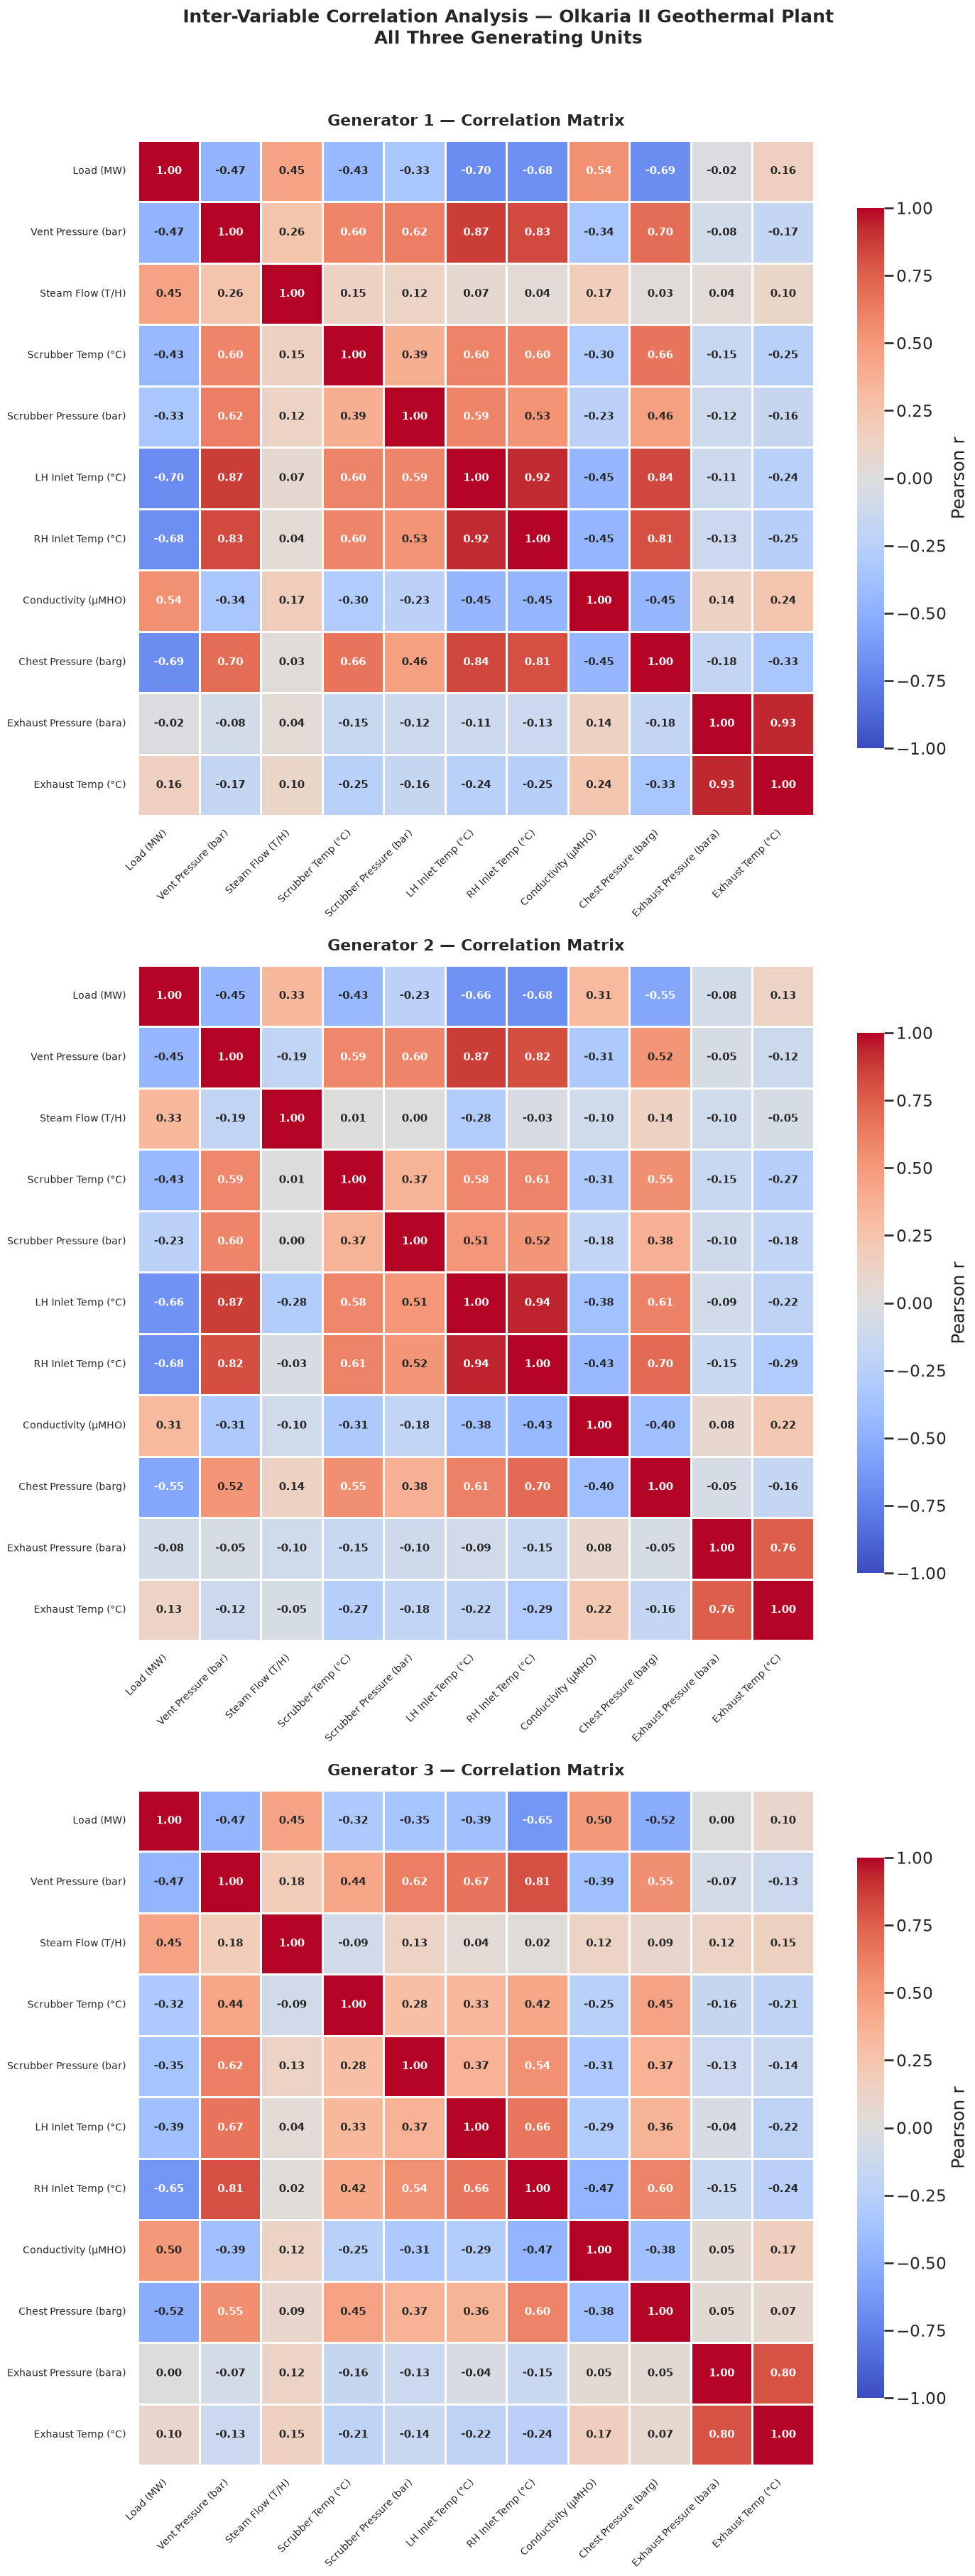

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 36))

for ax, (df, name) in zip(axes, [
    (gen1_clean, 'Generator 1'),
    (gen2_clean, 'Generator 2'),
    (gen3_clean, 'Generator 3')
]):
    corr = df.drop(columns=['date']).corr()

    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.8,
        linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        vmin=-1,
        vmax=1,
        cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
    )

    ax.set_title(
        f'{name} — Correlation Matrix',
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Clean readable tick labels
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.tick_params(axis='y', rotation=0, labelsize=11)

    # Clean up the label names for display
    clean_labels = [
        'Load (MW)', 'Vent Pressure (bar)', 'Steam Flow (T/H)',
        'Scrubber Temp (°C)', 'Scrubber Pressure (bar)',
        'LH Inlet Temp (°C)', 'RH Inlet Temp (°C)',
        'Conductivity (μMHO)', 'Chest Pressure (barg)',
        'Exhaust Pressure (bara)', 'Exhaust Temp (°C)'
    ]
    ax.set_xticklabels(clean_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(clean_labels, rotation=0, fontsize=10)

plt.suptitle(
    'Inter-Variable Correlation Analysis — Olkaria II Geothermal Plant\nAll Three Generating Units',
    fontsize=18,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

# Inter-Variable Correlation Analysis — Olkaria II Geothermal Plant

This analysis examines relationships between key operational variables across three generators at the Olkaria II geothermal plant. The objective is to identify dependencies, redundancies, and structural patterns that can inform feature engineering and modeling decisions.

- It is important to note that, features that have been labelled as redundant in relation to prediction but not diagnosis.

---

## Consistent patterns across all three generators

### Inlet temperatures are highly correlated
- LH Inlet Temperature and RH Inlet Temperature show near-perfect correlation (~0.92–0.94)
- Both variables move almost identically across all generators

Insight: These features are largely redundant and may represent the same underlying physical process.

---

### Exhaust system variables are strongly linked
- Exhaust Pressure and Exhaust Temperature show strong positive correlation (~0.76–0.93)
- Both increase and decrease together consistently

Insight: These two variables likely represent a tightly coupled subsystem.

---

### Vent pressure is strongly influenced by inlet conditions
- Vent Pressure correlates strongly with both inlet temperatures (~0.81–0.87)
- Changes in inlet conditions appear to directly affect vent behavior

---

### Load has a negative relationship with vent pressure
- Load (MW) shows moderate negative correlation with Vent Pressure (~-0.45 to -0.47)
- Higher load is associated with lower vent pressure

---

## Differences between generators

### Chest pressure behaves differently across units
- Generator 1 shows a strong correlation with inlet temperatures (~0.84)
- Generator 3 shows a much weaker relationship (~0.36)

Insight: Generator 3 exhibits more independent behavior in this variable.

---

### Conductivity remains largely independent
- Weak correlation with most variables across all generators
- Functions as an independent signal

Insight: Likely captures a different physical or chemical process not directly tied to thermal dynamics.

---

### Steam flow shows weak relationships
- Consistently weak correlation across all generators
- Does not strongly depend on other measured variables

---

## Key takeaways for modeling

### Feature redundancy in inlet temperatures
- LH and RH inlet temperatures carry almost identical information
- One of them may be removed to reduce multicollinearity

---

### Independent predictors
- Conductivity and steam flow provide unique and independent signals
- These should be retained for model robustness

---

### Exhaust variables form a cluster
- Exhaust pressure and exhaust temperature should be treated as a coupled feature group
- Consider combining or engineering joint features

---

## Conclusion

The system is characterized by:
- Strongly coupled thermal dynamics (inlet and exhaust systems)
- Partially independent operational signals (conductivity and steam flow)

Understanding these relationships is important for building stable and generalizable predictive models for geothermal plant operations.